In [1]:
import os
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as lines
import numpy as np
import seaborn as sns
from scipy.stats import spearmanr
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from matplotlib.ticker import FormatStrFormatter

In [ ]:
# settings
work_directory = r'C:\Users\...'
os.chdir(work_directory)

# setting: font
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)  # pass in the font dict as kwargs

In [ ]:
data0 = pd.read_csv('basins50.csv')
data0.head()

,OBSID1,OBSID2,STUDYID,CRN_SUBCMP,DBDOI,DBVERNO,CNTRY,REGION_INT,BASIN,AHGFL1,...,k_0,k_range_0,D_0,E_0,W_0,k_0b,k_range_0b,D_0b,E_0b,W_0b
0,S141WTS002,Yan,S141,INT,10.71747/uow-r3gk326m.28216865.v1,v2.3(4),IND,Transhimalaya,Tsomoriri lake,NaN,...,0.146031,Yes,22.7843,22.7843,0.0,0.075788,Yes,23.6912,23.6912,0.0
1,S075WTS009,WR5,S075,INT,10.71747/uow-r3gk326m.28216865.v1,v2.3(4),USA,Washington Cascades (WA),ND,NaN,...,0.870353,Yes,242.8740,242.8740,0.0,0.437291,Yes,245.2670,245.2670,0.0
2,S304WTS005,DB05,S304,INT,10.71747/uow-r3gk326m.28216865.v1,v2.3(4),ITA,W ITA Alps,Dora Baltea (trib.),NaN,...,2.251540,Yes,891.6570,891.6570,0.0,1.126130,Yes,895.1370,895.1370,0.0
3,S293WTS010,T10,S293,INT,10.71747/uow-r3gk326m.28216865.v1,v2.3(4),CHN,E Himalayan Syntaxis,Parlung tributary,NaN,...,2.371890,Yes,833.5030,833.5030,0.0,1.184160,Yes,834.2250,834.2250,0.0
4,S101WTS021,Nurla,S101,INT,10.71747/uow-r3gk326m.28216865.v1,v2.3(4),IND,Transhimalaya,Upper Indus,NaN,...,0.105162,Yes,33.5148,33.5148,0.0,0.053478,Yes,34.1966,34.1966,0.0


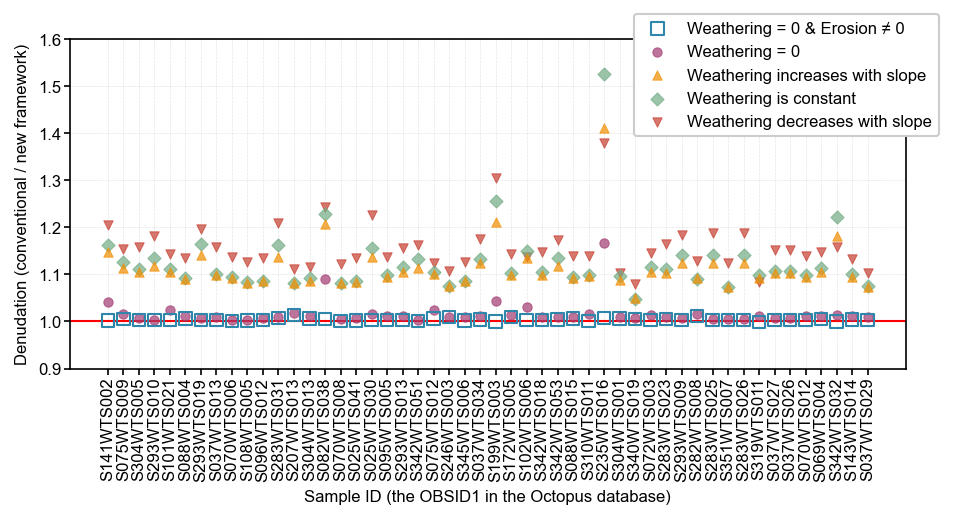

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(6.4,3.5), tight_layout=True, dpi=150)
fig.tight_layout(pad=2.5)

# Define modern color palette
colors = {
    'weathering_erosion': '#2E86AB',  # Deep blue
    'weathering_zero': '#A23B72',      # Purple
    'weathering_up': '#F18F01',        # Orange
    'weathering_constant': '#73AB84',  # Sage green
    'weathering_down': '#C73D2F'       # Terracotta red
}

data0['y_0b'] = data0['Denu'] / data0['D_0b']
x = list(data0['OBSID1'])
y = data0['y_0b']
ax.scatter(x, y, facecolors='none', edgecolors=colors['weathering_erosion'], marker='s', s=35, linewidths=1.0, zorder=5,
           label='Weathering = 0 & Erosion ≠ 0')

data0['y_0'] = data0['Denu'] / data0['D_0']
x = list(data0['OBSID1'])
y = data0['y_0']
ax.scatter(x, y, c=colors['weathering_zero'], marker='o', s=20, linewidths=0.5, zorder=4, alpha=0.7, label='Weathering = 0')

data0['y_i'] = data0['Denu'] / data0['D_i']
x = list(data0['OBSID1'])
y = data0['y_i']
ax.scatter(x, y, c=colors['weathering_up'], marker='^', s=20, linewidths=0.5, zorder=3, alpha=0.7, label='Weathering increases with slope')

data0['y_c'] = data0['Denu'] / data0['D_c']
x = list(data0['OBSID1'])
y = data0['y_c']
ax.scatter(x, y, c=colors['weathering_constant'], marker='D', s=20, linewidths=0.5, zorder=2, alpha=0.7, label='Weathering is constant')

data0['y_d'] = data0['Denu'] / data0['D_d']
x = list(data0['OBSID1'])
y = data0['y_d']
ax.scatter(x, y, c=colors['weathering_down'], marker='v', s=20, linewidths=0.5, zorder=1, alpha=0.7, label='Weathering decreases with slope')

ax.axhline(y=1,xmin=-100, xmax=1100, color='red', linewidth=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.set_yticks([0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5,1.6])
ax.set_xticks(ticks=x, labels=sorted(data0['OBSID1']))
ax.set_xlabel('Sample ID (the OBSID1 in the Octopus database)')
ax.set_xticklabels(x, rotation=90, fontsize=8)
# ax.set_xticklabels(x, rotation=45, ha='right', fontsize=6)  # Reduced rotation for better readability
ax.tick_params(axis='both', length=3, pad=1)
ax.set_ylabel('Denudation (conventional / new framework)')
ax.grid(color='gray', linestyle=':', linewidth=0.25, alpha=0.5)

ax.legend(framealpha=1, loc='upper right', bbox_to_anchor=(1.05, 1.1))

# fig.savefig('Results/260324/Figure3.jpg', dpi=300)